## PsyCoMark — Reproducible EDA & Split (dup-aware)

Covers:
- Data loading + normalization (+ dataset SHA-256 fingerprint)
- Span audits, overlap/nesting, per-label lengths, IoU diagnostics
- Subreddit×label heatmaps
- Duplicate detection (exact + near via SimHash+LSH) and calibration sweep
- **Deduped corpus** creation
- **Duplicate-aware train/dev split** with big-subreddit coverage
- **Zero cross-split dup** verification
- Exports: train/dev JSONL, class weights, length priors, spans, manifes
Repro tips:
- Keep `OUT_ROOT` under project control; every run writes to a stamped dir.
- Manifest stores inputs, config, hashes, counts, and versions

### 0) Imports & Config (deterministic)

In [4]:
import os, sys, json, math, time, re, hashlib, datetime
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 200)

# --------- Paths (override via env if needed) ----------
DATA_DIR   = Path(os.getenv("PSYCOMARK_DATA_DIR", "."))
REHYDRATED = Path(os.getenv("PSYCOMARK_REHYDRATED", DATA_DIR / "train_rehydrated.jsonl"))
REDACTED   = Path(os.getenv("PSYCOMARK_REDACTED",   DATA_DIR / "train_redacted.jsonl"))

OUT_ROOT   = Path(os.getenv("PSYCOMARK_OUT", "./eda_out_new"))
STAMP      = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUTDIR     = OUT_ROOT / STAMP
OUTDIR.mkdir(parents=True, exist_ok=True)

# --------- Constants ----------
ALLOWED_MARKERS   = {"Actor","Action","Effect","Victim","Evidence"}
DOC_LABELS        = ["conspiracy","non","cant_tell"]
IOU_THRESH        = 0.5
SEED              = int(os.getenv("PSYCOMARK_SEED", "42"))
np.random.seed(SEED)

# Near-dup defaults (high precision from your sweep)
LSH_BANDS_DEFAULT = 8
HAM_DEFAULT       = 4

print("pandas:", pd.__version__, "| numpy:", np.__version__)
print("OUTDIR:", OUTDIR.resolve())

pandas: 2.3.2 | numpy: 2.3.3
OUTDIR: C:\Users\panagiotis\Desktop\GitHub\semeval26_task10_starter_pack\eda_out_new\20250928_182248


### 1) Utilities

In [ ]:
def sha256_file(path: Path, block_size=1<<20) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            b = f.read(block_size)
            if not b: 
                break
            h.update(b)
    return h.hexdigest()

def sha256_jsonl(path: Path, n_preview: int = 3) -> dict:
    """Hash of full file + first lines preview to capture data identity."""
    info = {"exists": path.exists()}
    if not path.exists():
        return info
    info["sha256"] = sha256_file(path)
    info["size_bytes"] = path.stat().st_size
    info["preview"] = []
    with path.open("r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= n_preview: 
                break
            info["preview"].append(line[:200])
    return info

def load_jsonl(p: Path) -> List[Dict]:
    data = []
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: 
                continue
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                first = line.find("{")
                last = line.rfind("}")
                if first != -1 and last != -1 and last > first:
                    try: 
                        data.append(json.loads(line[first:last+1]))
                    except Exception: 
                        pass
    return data

def prefer(a, b): return a if a not in (None, "") else b

def get_doc_id(rec: Dict) -> Optional[str]:
    for k in ("_id","id","doc_id","reddit_id","submission_id","source_id"):
        if k in rec: 
            return str(rec[k])
    return None

def get_subreddit(rec: Dict) -> Optional[str]:
    for k in ("subreddit","community","source_subreddit"):
        if k in rec: 
            return rec[k]
    return None

def get_text(rec: Dict) -> Optional[str]:
    for k in ("text","plain_text","content","submission_statement","ss_text"):
        v = rec.get(k)
        if isinstance(v, str) and v.strip(): 
            return v
    return None

def normalize_doc_label(value: Optional[str]) -> Optional[str]:
    if value is None: 
        return None
    v = str(value).strip().lower()
    mapping = {
        "yes":"conspiracy","y":"conspiracy","consp":"conspiracy","conspiracy":"conspiracy",
        "no":"non","n":"non","non":"non","not conspiracy":"non",
        "can't tell":"cant_tell","cant tell":"cant_tell","cant_tell":"cant_tell","uncertain":"cant_tell","unknown":"cant_tell"
    }
    return mapping.get(v, None)

def get_doc_label(rec: Dict) -> Optional[str]:
    for k in ("conspiracy","conspiracy_label","binary_label","doc_label","label","is_conspiracy"):
        if k in rec:
            lab = rec[k]
            if isinstance(lab, dict): 
                lab = prefer(lab.get("label"), lab.get("value"))
            return normalize_doc_label(lab)
    return None

def get_markers(rec: Dict) -> List[Dict]:
    container = None
    for k in ("markers","spans","annotations"):
        if isinstance(rec.get(k), list):
            container = rec[k]
            break
    if container is None: 
        return []
    out = []
    aliases = {"actors":"Actor","actions":"Action","effects":"Effect","victims":"Victim","evidences":"Evidence"}
    for m in container:
        if not isinstance(m, dict): 
            continue
        label = m.get("label") or m.get("type") or m.get("name")
        if isinstance(label, dict): 
            label = prefer(label.get("label"), label.get("value"))
        if not label: 
            continue
        label_norm = aliases.get(str(label).strip().lower(), str(label).strip().capitalize())
        if label_norm not in ALLOWED_MARKERS: 
            continue
        s = m.get("startIndex", m.get("start", m.get("begin")))
        e = m.get("endIndex", m.get("end", m.get("finish")))
        t = m.get("text", m.get("span_text"))
        try: 
            s = int(s) if s is not None else None
            e = int(e) if e is not None else None
        except Exception: 
            s, e = None, None
        out.append({"label":label_norm, "start":s, "end":e, "text": t if isinstance(t,str) else None})
    return out

def spans_overlap(a: Tuple[int,int], b: Tuple[int,int]) -> bool:
    return max(a[0], b[0]) < min(a[1], b[1])

def is_nested(inner: Tuple[int,int], outer: Tuple[int,int]) -> bool:
    return outer[0] <= inner[0] and inner[1] <= outer[1]

def iou_char(a: Tuple[int,int], b: Tuple[int,int]) -> float:
    inter = max(0, min(a[1], b[1]) - max(a[0], b[0]))
    union = max(a[1]-a[0], 0) + max(b[1]-b[0], 0) - inter
    return inter / union if union > 0 else 0.0

# ---- Duplicate helpers ----
def normalize_for_dup(s: str) -> str:
    return " ".join((s or "").lower().split())

def text_hash(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

def tokenize_for_simhash(s: str) -> List[str]:
    return re.findall(r"\w+", s.lower())

def simhash64(tokens: List[str]) -> int:
    v = [0]*64
    for t in tokens:
        h = int(hashlib.md5(t.encode("utf-8")).hexdigest(), 16)
        for i in range(64):
            v[i] += 1 if ((h>>i)&1) else -1
    out = 0
    for i in range(64):
        if v[i] >= 0:
            out |= (1<<i)
    return out

def hamming64(a:int,b:int) -> int: return (a^b).bit_count()

def lsh_buckets(simhash_val: int, bands: int) -> List[Tuple[int,int]]:
    assert 64 % bands == 0
    r = 64 // bands
    out = []
    for b in range(bands):
        start = b*r; mask = ((1<<r)-1) << start
        out.append((b, (simhash_val & mask) >> start))
    return out

# ---- Union-Find ----
class UF:
    def __init__(self, n): self.p=list(range(n)); self.r=[0]*n
    def find(self,x):
        while self.p[x]!=x:
            self.p[x]=self.p[self.p[x]]
            x=self.p[x]
        return x
    def union(self,a,b):
        ra, rb = self.find(a), self.find(b)
        if ra==rb: 
            return
        if self.r[ra]<self.r[rb]: 
            self.p[ra]=rb
        elif self.r[ra]>self.r[rb]:
            self.p[rb]=ra
        else: 
            self.p[rb]=ra
            self.r[ra]+=1

def stable_shuffle(idxs, key: str):
    rng = np.random.RandomState(int(hashlib.md5(key.encode()).hexdigest(), 16) % (2**32))
    idxs = list(idxs)
    rng.shuffle(idxs)
    return idxs

### 2) Load data (rehydrated preferred) + dataset fingerprints

In [6]:
source_used = None
if REHYDRATED.exists():
    records = load_jsonl(REHYDRATED); source_used = "rehydrated"
elif REDACTED.exists():
    records = load_jsonl(REDACTED);   source_used = "redacted"
else:
    raise FileNotFoundError("Neither rehydrated nor redacted JSONL found.")

print(f"[LOAD] {len(records)} records from {source_used}")
src_info = {
    "rehydrated": sha256_jsonl(REHYDRATED),
    "redacted":   sha256_jsonl(REDACTED),
}
print(json.dumps(src_info, indent=2)[:500])

[LOAD] 4316 records from rehydrated
{
  "rehydrated": {
    "exists": true,
    "sha256": "52c4e753235e090a33602a1a798bda271a9290c3ec6a75531be92f497f3976b7",
    "size_bytes": 4378777,
    "preview": [
      "{\"_id\": \"t1_f7ju17o\", \"text\": \"A great article on what's taking place in Bolivia, referencing some similar US backed coups in the region as well as recounting some of Bolivia's history and western pol",
      "{\"_id\": \"t1_k5c5yyz\", \"text\": \"Chris Lehto interviews Ashton Forbes about his deep dive investigation i


### 3) Build normalized DataFrame (+ enforce unique doc_id upstream)

In [8]:
def build_dataframe(records: List[Dict], prefer_text: bool) -> pd.DataFrame:
    rows=[]
    for rec in records:
        rid = get_doc_id(rec) or None
        rows.append({
            "doc_id":    rid,
            "subreddit": get_subreddit(rec),
            "text":      get_text(rec) if prefer_text else None,
            "doc_label": get_doc_label(rec),
            "markers":   get_markers(rec),
        })
    df = pd.DataFrame(rows)
    if df["doc_id"].isna().any():
        df["doc_id"] = df["doc_id"].fillna(df.index.map(lambda i: f"doc_{i:07d}"))
    # Enforce uniqueness now (keeps first deterministically)
    before = len(df)
    df = df.sort_values("doc_id").drop_duplicates("doc_id", keep="first").reset_index(drop=True)
    print(f"[unique doc_id] {before} -> {len(df)}")
    return df

df = build_dataframe(records, prefer_text=(source_used=="rehydrated"))
n_docs = len(df)
print("has_text_frac:", df["text"].notna().mean())

[unique doc_id] 4316 -> 3682
has_text_frac: 1.0


### 4) Span audits, overlaps, per-label lengths

,metric,value
0,num_docs,3682.0000
1,unique_subreddits,191.0000
2,has_text_fraction,1.0000
3,avg_spans_per_doc,5.0820
4,span_bounds_ok_fraction,1.0000
5,span_text_match_ok_fraction,1.0000
6,doc_overlap_fraction,0.2390
7,doc_nested_fraction,0.2232


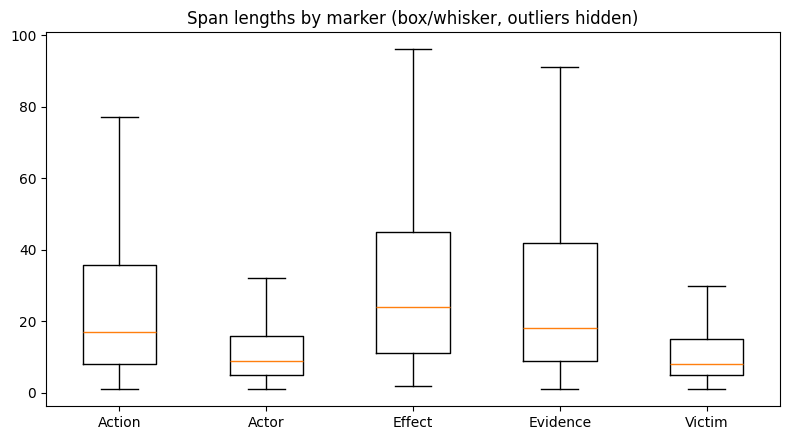

In [13]:
def audit_offsets(df: pd.DataFrame) -> pd.DataFrame:
    recs = []
    for _, row in df.iterrows():
        text = row.get("text", None)
        did  = row["doc_id"]
        for j, m in enumerate(row["markers"] or []):
            s, e, label, span_txt = m["start"], m["end"], m["label"], m["text"]
            bounds_ok = (text is not None and isinstance(s,int) and isinstance(e,int) and 0<=s<e<=len(text))
            match_ok=False
            if bounds_ok:
                extracted = text[s:e]
                match_ok = True if span_txt is None else (
                    extracted == span_txt or (" ".join(extracted.split()) == " ".join(span_txt.split()))
                )
            recs.append({"doc_id":did,"idx_in_doc":j,"label":label,"start":s,"end":e,
                         "char_len": (e-s) if (isinstance(s,int) and isinstance(e,int)) else None,
                         "bounds_ok":bool(bounds_ok),"text_match_ok":bool(match_ok),"has_text":text is not None})
    return pd.DataFrame(recs)

df_spans = audit_offsets(df) if (source_used=="rehydrated") else pd.DataFrame(columns=[
    "doc_id","idx_in_doc","label","start","end","char_len","bounds_ok","text_match_ok","has_text"
])

def compute_overlap_stats(df_docs: pd.DataFrame) -> pd.DataFrame:
    rows=[]
    for _, row in df_docs.iterrows():
        spans = [(m["label"], m["start"], m["end"]) for m in (row["markers"] or [])
                 if isinstance(m.get("start"),int) and isinstance(m.get("end"),int) and m["end"]>m["start"]]
        spans.sort(key=lambda x:(x[1],x[2]))
        n=len(spans); overlaps=nested=cross_type=same_type=0
        for i in range(n):
            li, si, ei = spans[i]
            for j in range(i+1,n):
                lj, sj, ej = spans[j]
                if sj >= ei: break
                if spans_overlap((si,ei),(sj,ej)):
                    overlaps += 1
                    if is_nested((sj,ej),(si,ei)) or is_nested((si,ei),(sj,ej)): nested += 1
                    if li==lj: same_type += 1
                    else: cross_type += 1
        rows.append({"doc_id":row["doc_id"],"n_spans":n,"has_overlap":overlaps>0,
                     "overlap_pairs":overlaps,"nested_pairs":nested,
                     "cross_type_pairs":cross_type,"same_type_pairs":same_type})
    return pd.DataFrame(rows)

df_overlap = compute_overlap_stats(df)

# Summaries
summary = pd.DataFrame([
    ["num_docs", n_docs],
    ["unique_subreddits", int(df["subreddit"].dropna().nunique())],
    ["has_text_fraction", round(float(df["text"].notna().mean()),4)],
    ["avg_spans_per_doc", round(float(df["markers"].apply(lambda m: len(m) if isinstance(m,list) else 0).mean()),4)],
    ["span_bounds_ok_fraction", round(float(df_spans["bounds_ok"].mean()),4) if len(df_spans) else None],
    ["span_text_match_ok_fraction", round(float(df_spans["text_match_ok"].mean()),4) if len(df_spans) else None],
    ["doc_overlap_fraction", round(float(df_overlap["has_overlap"].mean()),4)],
    ["doc_nested_fraction", round(float((df_overlap["nested_pairs"]>0).mean()),4)],
], columns=["metric","value"])
display(summary)
summary.to_csv(OUTDIR / "summary.csv", index=False)

# Label distribution
lbl_counts = df["doc_label"].value_counts()
pd.DataFrame({
    "label": lbl_counts.index, "count": lbl_counts.values,
    "fraction": (lbl_counts / max(1,lbl_counts.sum())).round(4).values
}).to_csv(OUTDIR / "doc_label_distribution.csv", index=False)

# Marker counts
mk_counts = pd.Series([
    m["label"] for _, r in df.iterrows() for m in (r["markers"] or [])
]).value_counts().reindex(sorted(ALLOWED_MARKERS)).fillna(0).astype(int)
pd.DataFrame({"marker": mk_counts.index, "count": mk_counts.values}).to_csv(OUTDIR / "marker_label_counts.csv", index=False)

# Plots: labels & markers
plt.figure(); plt.bar(lbl_counts.index.astype(str), lbl_counts.values)
plt.title("Document label distribution"); plt.tight_layout()
plt.savefig(OUTDIR / "doc_label_distribution.png"); plt.close()

plt.figure(); plt.bar(mk_counts.index.astype(str), mk_counts.values)
plt.title("Marker label counts"); plt.tight_layout()
plt.savefig(OUTDIR / "marker_label_counts.png"); plt.close()

# Per-label length quantiles & boxplots
if len(df_spans):
    q_levels=[0.1,0.25,0.5,0.75,0.9]
    rows=[]
    for lab, grp in df_spans.groupby("label"):
        s = grp["char_len"].dropna().astype(int)
        if not len(s): continue
        qs = np.quantile(s, q_levels)
        rows.append({"label":lab, **{f"q{int(q*100)}": int(v) for q,v in zip(q_levels,qs)}})
    qtab = pd.DataFrame(rows).sort_values("label")
    qtab.to_csv(OUTDIR / "span_length_quantiles.csv", index=False)

    labs_sorted = sorted(ALLOWED_MARKERS)
    data_for_box=[df_spans[df_spans["label"]==lab]["char_len"].dropna().astype(int).values for lab in labs_sorted]
    plt.figure(figsize=(8,4.5)); plt.boxplot(data_for_box, tick_labels=labs_sorted, showfliers=False)
    plt.title("Span lengths by marker (box/whisker, outliers hidden)")
    plt.tight_layout()
    plt.savefig(OUTDIR / "span_length_boxplots.png")
    #plt.close()

### 5) IoU diagnostics (Action–Effect, Effect–Victim) + Mean IoU matrix

('Action', 'Effect') N= 230 mean= 0.559 median= 0.477
('Effect', 'Victim') N= 246 mean= 0.289 median= 0.209


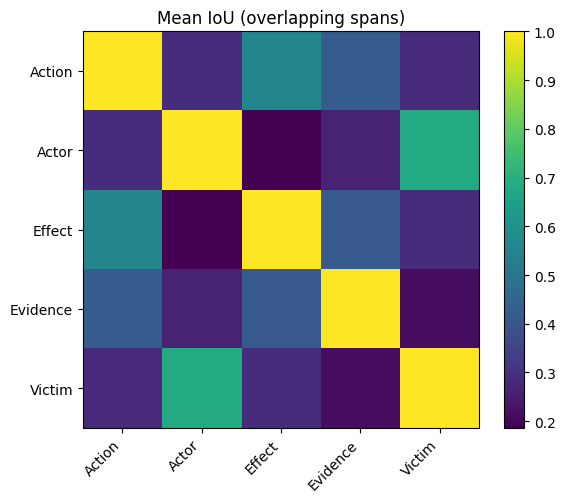

In [14]:
# IoU collection for pairs of interest
pairs_to_probe=[("Action","Effect"),("Effect","Victim")]
iou_values={p:[] for p in pairs_to_probe}

for _, row in df.iterrows():
    spans = [(m["label"], m["start"], m["end"]) for m in (row["markers"] or [])
             if isinstance(m.get("start"),int) and isinstance(m.get("end"),int) and m["end"]>m["start"]]
    spans.sort(key=lambda x:(x[1],x[2]))
    by_lab=defaultdict(list)
    for lab,s,e in spans: 
        by_lab[lab].append((s,e))
    for a,b in pairs_to_probe:
        for (si,ei) in by_lab.get(a, []):
            for (sj,ej) in by_lab.get(b, []):
                if max(si,sj) < min(ei,ej):
                    v = iou_char((si,ei),(sj,ej))
                    if v>0: 
                        iou_values[(a,b)].append(v)

for pair, vals in iou_values.items():
    v = np.array(vals, dtype=float)
    if len(v)==0: 
        continue
    print(pair, "N=",len(v),"mean=",v.mean().round(3),"median=",np.median(v).round(3))
    plt.figure(figsize=(6,4))
    plt.hist(v, bins=20)
    plt.title(f"IoU histogram: {pair[0]} + {pair[1]}")
    plt.tight_layout()
    plt.savefig(OUTDIR / f"iou_hist_{pair[0]}_{pair[1]}.png")
    plt.close()
    pd.DataFrame({"iou": v}).to_csv(OUTDIR / f"iou_values_{pair[0]}_{pair[1]}.csv", index=False)

# Mean IoU matrix for overlapping pairs (diagnostic)
labels_sorted = sorted(ALLOWED_MARKERS)
sum_iou=defaultdict(float)
cnt_iou=defaultdict(int)
for _, row in df.iterrows():
    spans = [(m["label"], m["start"], m["end"]) for m in (row["markers"] or [])
             if isinstance(m.get("start"),int) and isinstance(m.get("end"),int) and m["end"]>m["start"]]
    for i in range(len(spans)):
        li, si, ei = spans[i]
        for j in range(i+1, len(spans)):
            lj, sj, ej = spans[j]
            if not spans_overlap((si,ei),(sj,ej)): 
                continue
            a,b = sorted([li,lj])
            sum_iou[(a,b)] += iou_char((si,ei),(sj,ej))
            cnt_iou[(a,b)] += 1

mat = np.zeros((len(labels_sorted),len(labels_sorted)), dtype=float)
for i,a in enumerate(labels_sorted):
    for j,b in enumerate(labels_sorted):
        if i==j: 
            mat[i,j]=1.0
        else:
            key=tuple(sorted([a,b]))
            if cnt_iou.get(key,0):
                mat[i,j] = sum_iou[key]/cnt_iou[key]

plt.figure(figsize=(6,5)); plt.imshow(mat, interpolation="nearest")
plt.xticks(range(len(labels_sorted)), labels_sorted, rotation=45, ha="right")
plt.yticks(range(len(labels_sorted)), labels_sorted); plt.colorbar()
plt.title("Mean IoU (overlapping spans)")
plt.tight_layout()
plt.savefig(OUTDIR / "mean_iou_matrix.png")
#plt.close()
pd.DataFrame(mat, index=labels_sorted, columns=labels_sorted).round(3).to_csv(OUTDIR / "mean_iou_matrix.csv")

### 6) Subreddit × label heatmaps (top 30)

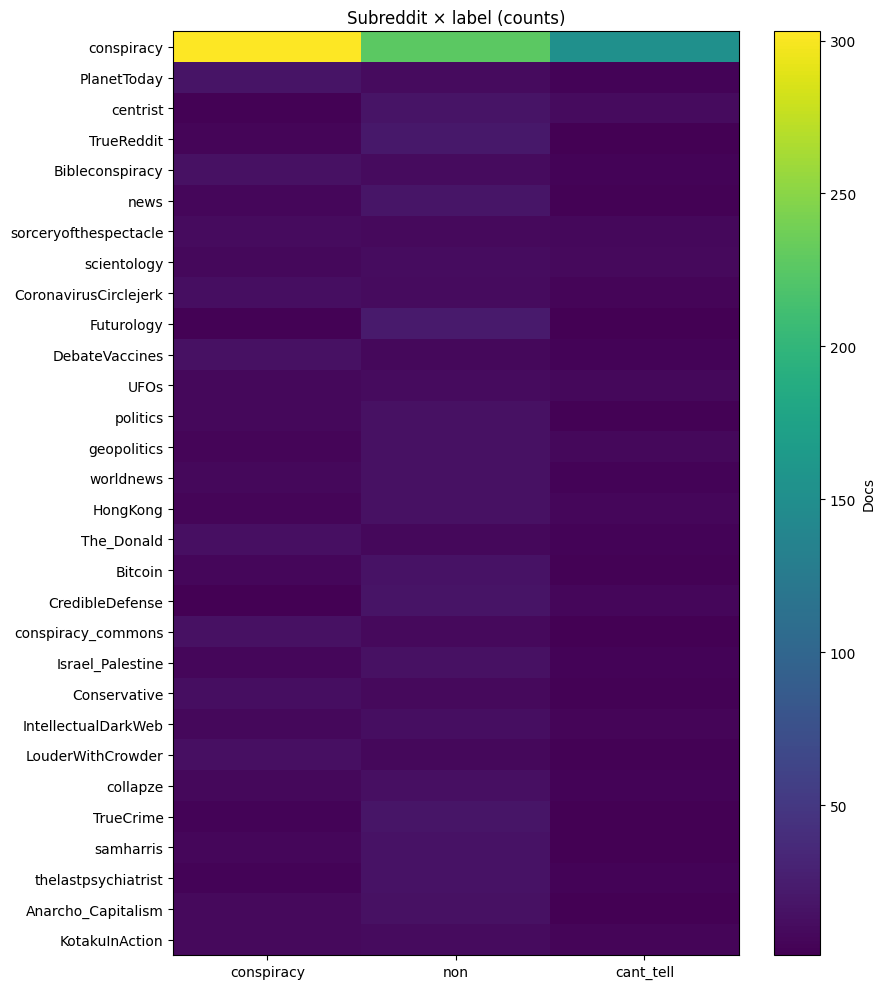

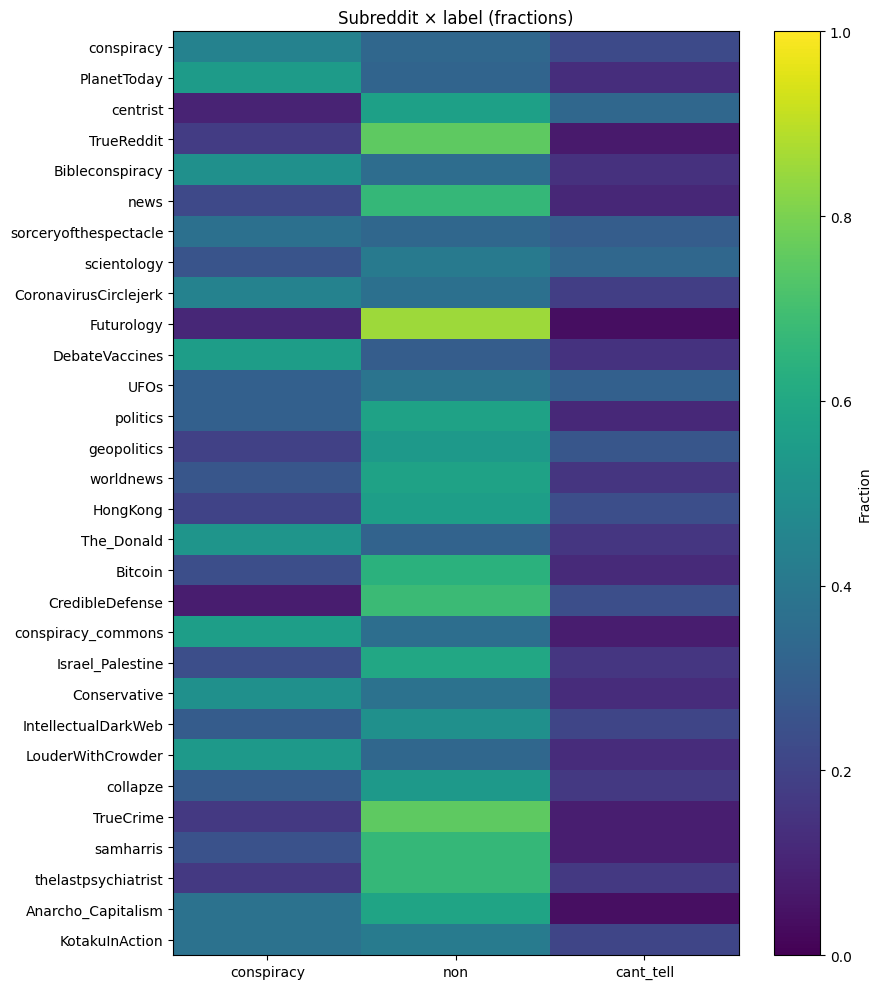

In [15]:
top_k = 30
subs_top = df["subreddit"].value_counts().head(top_k).index.tolist()
sub_df = df[df["subreddit"].isin(subs_top)].copy()

pivot_counts = pd.pivot_table(sub_df, index="subreddit", columns="doc_label",
                              values="doc_id", aggfunc="count", fill_value=0)
for c in DOC_LABELS:
    if c not in pivot_counts.columns: 
        pivot_counts[c]=0
pivot_counts = pivot_counts[DOC_LABELS].loc[subs_top]

pivot_frac = pivot_counts.div(pivot_counts.sum(axis=1).replace(0,1), axis=0)

plt.figure(figsize=(9,10))
plt.imshow(pivot_counts.values, aspect="auto")
plt.colorbar(label="Docs")
plt.xticks(range(3), DOC_LABELS)
plt.yticks(range(len(subs_top)), subs_top)
plt.title("Subreddit × label (counts)")
plt.tight_layout()
plt.savefig(OUTDIR / "subreddit_label_heatmap_counts.png")
#plt.close()

plt.figure(figsize=(9,10))
plt.imshow(pivot_frac.values, aspect="auto", vmin=0, vmax=1)
plt.colorbar(label="Fraction")
plt.xticks(range(3), DOC_LABELS)
plt.yticks(range(len(subs_top)), subs_top)
plt.title("Subreddit × label (fractions)")
plt.tight_layout()
plt.savefig(OUTDIR / "subreddit_label_heatmap_fractions.png")
#plt.close()

pivot_counts.to_csv(OUTDIR / "subreddit_label_counts_top30.csv")
pivot_frac.round(3).to_csv(OUTDIR / "subreddit_label_fractions_top30.csv")

### 7) Duplicate report (exact & near) + calibration sweep

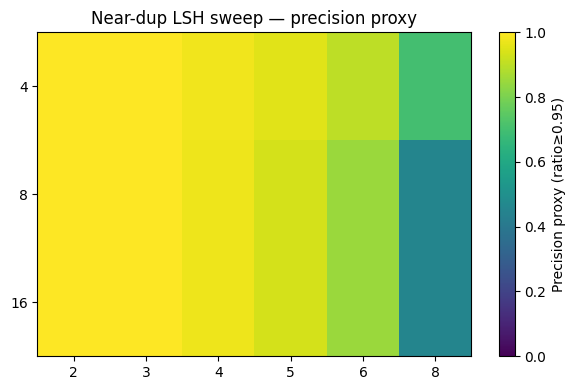

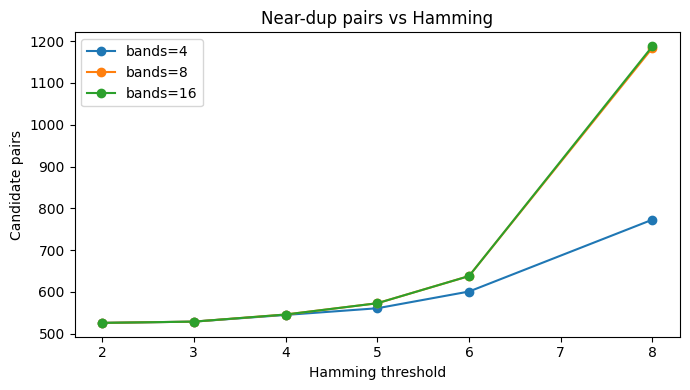

In [16]:
docs_hash = df[["doc_id","text"]].copy()
docs_hash["norm_text"] = docs_hash["text"].fillna("").apply(normalize_for_dup)
docs_hash["exact_hash"] = docs_hash["norm_text"].apply(text_hash)
docs_hash["tokens"] = docs_hash["norm_text"].apply(tokenize_for_simhash)
docs_hash["simhash64"] = docs_hash["tokens"].apply(simhash64)

# Exact dup clusters
clusters = docs_hash.groupby("exact_hash")["doc_id"].apply(list).reset_index()
clusters["size"] = clusters["doc_id"].apply(len)
exact_dupe_clusters = clusters[clusters["size"]>1].copy()
exact_dupe_clusters.to_csv(OUTDIR / "duplicates_exact_clusters.csv", index=False)

# Near-dup candidate generation with LSH
def lsh_candidates(simvals: List[int], bands: int) -> set[tuple[int,int]]:
    bucket_map=defaultdict(list)
    for idx, val in enumerate(simvals):
        for key in lsh_buckets(val, bands=bands): 
            bucket_map[key].append(idx)
    cand=set()
    for _, idxs in bucket_map.items():
        if len(idxs)<2: continue
        idxs=sorted(idxs)
        for i in range(len(idxs)):
            for j in range(i+1,len(idxs)): 
                cand.add((idxs[i], idxs[j]))
    return cand

bands_grid=[4,8,16]; ham_grid=[2,3,4,5,6,8]
def seq_ratio(a: str, b: str) -> float:
    import difflib
    return difflib.SequenceMatcher(None, a, b).ratio()

sweep_rows=[]
simvals = docs_hash["simhash64"].tolist()
for b in bands_grid:
    assert 64 % b == 0
    cand = lsh_candidates(simvals, bands=b)
    # evaluate per ham
    for h in ham_grid:
        survivors=[]
        for i,j in cand:
            if hamming64(int(simvals[i]), int(simvals[j])) <= h:
                survivors.append((i,j))
        # precision proxy on sample
        n_pairs=len(survivors)
        if n_pairs==0:
            sweep_rows.append({"bands":b,"ham":h,"pairs":0,"prec_proxy":None,"prec_proxy_n":0}); continue
        idxs = np.random.default_rng(SEED).choice(n_pairs, size=min(4000,n_pairs), replace=False)
        tp=0
        for k in idxs:
            i,j = survivors[int(k)]
            if seq_ratio(docs_hash.iloc[i]["norm_text"], docs_hash.iloc[j]["norm_text"]) >= 0.95:
                tp += 1
        prec = tp/len(idxs)
        sweep_rows.append({"bands":b,"ham":h,"pairs":n_pairs,"prec_proxy":round(prec,4),"prec_proxy_n":int(len(idxs))})

sweep_df = pd.DataFrame(sweep_rows).sort_values(["bands","ham"])
sweep_df.to_csv(OUTDIR / "near_dupe_lsh_sweep.csv", index=False)

# Save an informative figure or two
plt.figure(figsize=(6,4))
pivot = sweep_df.pivot(index="bands", columns="ham", values="prec_proxy")
plt.imshow(pivot.values, aspect="auto", vmin=0, vmax=1)
plt.colorbar(label="Precision proxy (ratio≥0.95)")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Near-dup LSH sweep — precision proxy")
plt.tight_layout()
plt.savefig(OUTDIR / "near_dupe_lsh_prec_proxy.png")
# plt.close()

plt.figure(figsize=(7,4))
for b, g in sweep_df.groupby("bands"):
    plt.plot(g["ham"], g["pairs"], marker="o", label=f"bands={b}")
plt.xlabel("Hamming threshold"); plt.ylabel("Candidate pairs")
plt.title("Near-dup pairs vs Hamming")
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "near_dupe_lsh_pairs.png")
#plt.close()

### 8) Deduped corpus creation

In [18]:
# Drop all but one per exact-dup cluster (keep longest text; tie-break lexicographically)
df_pruned = df.copy()
if len(exact_dupe_clusters):
    to_drop=[]
    for _, row in exact_dupe_clusters.iterrows():
        ids = row["doc_id"] if isinstance(row["doc_id"], list) else json.loads(row["doc_id"])
        sub = df_pruned[df_pruned["doc_id"].isin(ids)].copy()
        if sub.empty: continue
        sub["len"] = sub["text"].fillna("").str.len()
        keep_id = sub.sort_values(["len","doc_id"], ascending=[False,True]).iloc[0]["doc_id"]
        drop_ids = [i for i in sub["doc_id"] if i != keep_id]
        to_drop.extend(drop_ids)
    df_pruned = df_pruned[~df_pruned["doc_id"].isin(set(to_drop))].reset_index(drop=True)
    print(f"[dedup] Dropped {len(set(to_drop))} exact-duplicate docs.")

# Final guard: unique doc_id
if not df_pruned["doc_id"].is_unique:
    print("[fix] df_pruned had duplicate doc_id rows; deduplicating")
    df_pruned = df_pruned.sort_values("doc_id").drop_duplicates("doc_id", keep="first").reset_index(drop=True)

print("[pruned] num_docs:", len(df_pruned))
print("[pruned] label distribution:\n", df_pruned["doc_label"].value_counts())


[dedup] Dropped 292 exact-duplicate docs.
[pruned] num_docs: 3390
[pruned] label distribution:
 doc_label
non           1603
conspiracy    1172
cant_tell      615
Name: count, dtype: int64


### 9) Duplicate-aware split (components as groups) w/ big-subreddit coverage

In [ ]:

# Build duplicate components (exact + near, high precision) on pruned corpus
docs = df_pruned[["doc_id","subreddit","doc_label","text"]].copy()
docs["norm_text"] = docs["text"].fillna("").apply(normalize_for_dup)
docs["exact_hash"] = docs["norm_text"].apply(text_hash)
docs["tokens"] = docs["norm_text"].apply(tokenize_for_simhash)
docs["simhash64"] = docs["tokens"].apply(simhash64)

# Union-Find
N=len(docs); uf=UF(N)
# exact unions
for _, idxs in docs.groupby("exact_hash").indices.items():
    idxs=list(idxs)
    for i in range(1,len(idxs)): uf.union(idxs[0], idxs[i])
# near unions
BANDS=LSH_BANDS_DEFAULT 
HAM=HAM_DEFAULT
bucket_map=defaultdict(list)
simvals=docs["simhash64"].tolist()
for idx, val in enumerate(simvals):
    for key in lsh_buckets(val, bands=BANDS): 
        bucket_map[key].append(idx)
cand=set()
for _, idxs in bucket_map.items():
    if len(idxs)<2: 
        continue
    idxs=sorted(idxs)
    for i in range(len(idxs)):
        for j in range(i+1,len(idxs)): 
            cand.add((idxs[i], idxs[j]))
for i,j in cand:
    if hamming64(int(simvals[i]), int(simvals[j])) <= HAM:
        uf.union(i,j)

root=[uf.find(i) for i in range(N)]
docs["dup_comp"]=pd.Series(root, index=docs.index).astype(str)
comp_sizes = docs["dup_comp"].value_counts().to_dict()
docs["dup_comp_size"]=docs["dup_comp"].map(comp_sizes)

comp_df=(docs.groupby("dup_comp")
             .agg(size=("doc_id","count"),
                  subs=("subreddit", lambda s: sorted(s.unique().tolist())),
                  labels=("doc_label", lambda s: sorted(s.value_counts().to_dict().items(), key=lambda x:-x[1])))
             .reset_index())
comp_df.to_csv(OUTDIR / "dup_components_summary.csv", index=False)
print("components total:", comp_df.shape[0], "| multi-doc components:", int((comp_df["size"]>1).sum()))

# Build pseudo-groups by subreddit (for big-sub coverage)
def build_pseudo_groups(df_in, top_k=20, min_group_size=60, min_groups_for_big=2):
    counts = df_in["subreddit"].fillna("__unknown__").value_counts()
    cand_big = counts.head(top_k).index.tolist()
    groups={}; sub_to_groups={}
    for sub, sub_df in df_in.groupby("subreddit", dropna=False):
        idxs = sub_df.index.tolist()
        k = max(1, int(np.ceil(len(idxs)/min_group_size)))
        parts = np.array_split(stable_shuffle(idxs, f"{sub}::{len(idxs)}"), k)
        sub_to_groups[sub] = [f"{sub}#{gi}" for gi in range(len(parts))]
        for gi, chunk in enumerate(parts):
            for i in chunk: 
                groups[i] = f"{sub}#{gi}"
    big_subs = {sub for sub in cand_big if len(sub_to_groups.get(sub, [])) >= min_groups_for_big}
    gcol = df_in.index.to_series().map(groups)
    return gcol, sub_to_groups, big_subs

df_tmp = df_pruned.copy()
df_tmp["pseudo_group"], SUB_TO_GROUPS, BIG_SUBS = build_pseudo_groups(df_tmp, top_k=20, min_group_size=60, min_groups_for_big=2)
df_tmp["final_group"] = docs["dup_comp"].values  # split unit

# Preselect one component from each big subreddit into dev (coverage)
label_order = DOC_LABELS
global_prop = df_tmp["doc_label"].value_counts(normalize=True).reindex(label_order).fillna(0.0).values

def comp_prop(df_in, comp_id):
    sub = df_in[df_in["final_group"]==comp_id]
    return sub["doc_label"].value_counts(normalize=True).reindex(label_order).fillna(0.0).values, len(sub)

dev_comp=set(); dev_prop=np.zeros_like(global_prop); dev_n=0
for sub in sorted(BIG_SUBS, key=lambda s: -df_tmp[df_tmp["subreddit"]==s].shape[0]):
    comp_ids = df_tmp.loc[df_tmp["subreddit"]==sub, "final_group"].unique().tolist()
    best_c,best_obj=None,1e9
    for c in comp_ids:
        p,n = comp_prop(df_tmp, c)
        new_prop = (dev_prop*dev_n + p*n) / (dev_n+n if dev_n+n>0 else 1)
        obj = np.abs(new_prop - global_prop).sum()
        if obj < best_obj: best_obj, best_c = obj, c
    if best_c is not None:
        dev_comp.add(best_c)
        p,n = comp_prop(df_tmp, best_c)
        dev_prop = (dev_prop*dev_n + p*n) / (dev_n+n if dev_n+n>0 else 1)
        dev_n += n

# Fill remaining dev via GroupShuffle on components
from sklearn.model_selection import GroupShuffleSplit
DEV_FRAC = 0.15
target_dev = int(round(DEV_FRAC * len(df_tmp)))
pre_dev_docs = df_tmp[df_tmp["final_group"].isin(dev_comp)].shape[0]
rem_frac = max(0.0, min(0.9, (target_dev - pre_dev_docs)/max(1,len(df_tmp)-pre_dev_docs)))

def objective(dev_idx_all):
    dev = df_tmp.iloc[dev_idx_all]
    dev_prop = dev["doc_label"].value_counts(normalize=True).reindex(label_order).fillna(0.0).values
    l1 = np.abs(dev_prop - global_prop).sum()
    size_pen = abs(len(dev)/len(df_tmp) - DEV_FRAC)
    return l1 + 0.5*size_pen, (l1, size_pen)

best=None
best_obj=1e9
best_m=None
remain = df_tmp[~df_tmp["final_group"].isin(dev_comp)].copy()
gss = GroupShuffleSplit(n_splits=500, test_size=rem_frac, random_state=SEED)
for tr_idx_r, dv_idx_r in gss.split(remain.index, y=remain["doc_label"], groups=remain["final_group"]):
    dv_idx_all = list(df_tmp[df_tmp["final_group"].isin(dev_comp)].index) + list(remain.index[dv_idx_r])
    obj, metr = objective(dv_idx_all)
    if obj < best_obj: 
        best_obj, best, best_m = obj, dv_idx_all, metr

dev_idx = np.array(sorted(set(best)))
train_idx = np.array(sorted(set(df_tmp.index) - set(dev_idx)))

print(f"[dup-aware split] objective={best_obj:.4f} (label_l1={best_m[0]:.4f}, size_pen={best_m[1]:.4f})")
print("train/dev sizes:", len(train_idx), len(dev_idx))

split_series = pd.Series(index=df_tmp["doc_id"], data="train")
split_series.iloc[dev_idx] = "dev"
split_df = split_series.rename("split").reset_index().rename(columns={"index":"doc_id"})
# safety collapse: one row per doc_id (dev wins)
if not split_df["doc_id"].is_unique:
    split_df = (split_df.groupby("doc_id")["split"]
                        .apply(lambda s: "dev" if "dev" in set(s) else "train")
                        .reset_index())

# Label balance (one row per doc)
lbl = docs[["doc_id","doc_label"]].merge(split_df, on="doc_id")
print(lbl.groupby("split")["doc_label"].value_counts().unstack(fill_value=0))
print("dev total:", int((lbl["split"]=="dev").sum()))

components total: 3371 | multi-doc components: 17
[dup-aware split] objective=0.0031 (label_l1=0.0029, size_pen=0.0004)
train/dev sizes: 2883 507
doc_label  cant_tell  conspiracy   non
split                                 
dev               92         176   239
train            523         996  1364
dev total: 507


### 10) Split verification: zero cross-split duplicates, then save

In [ ]:
docs2 = docs.merge(split_df, on="doc_id")
cross_exact = (docs2.groupby("exact_hash")["split"].nunique() > 1).sum()
print("cross-split exact dup clusters:", int(cross_exact))

# near cross-split
bucket_map=defaultdict(list)
vals=docs2["simhash64"].tolist()
for idx,val in enumerate(vals):
    for key in lsh_buckets(val, bands=BANDS): 
        bucket_map[key].append(idx)
cand=set()
for _, idxs in bucket_map.items():
    if len(idxs)<2: 
        continue
    idxs=sorted(idxs)
    for i in range(len(idxs)):
        for j in range(i+1,len(idxs)): 
            cand.add((idxs[i], idxs[j]))

near_pairs=0
for i,j in cand:
    if hamming64(int(vals[i]), int(vals[j])) <= HAM:
        if docs2.iloc[i]["split"] != docs2.iloc[j]["split"]:
            near_pairs += 1
print("cross-split near-duplicate pairs:", near_pairs)

# Save split if clean
if cross_exact == 0 and near_pairs == 0:
    split_df.to_csv(OUTDIR / "split_map.csv", index=False)
    print("[saved] split_map.csv")
else:
    print("⚠️ Not saved: split has cross-split duplicates; adjust HAM/bands or grouping and retry.")

cross-split exact dup clusters: 0
cross-split near-duplicate pairs: 0
[saved] split_map.csv


### 11) Exports for modeling: train/dev JSONL, class weights, length priors, span

In [ ]:
# spans table from pruned data
span_rows=[]
for _, r in df_pruned.iterrows():
    for m in (r["markers"] or []):
        s, e, lab = m.get("start"), m.get("end"), m.get("label")
        if isinstance(s,int) and isinstance(e,int) and e>s and lab in ALLOWED_MARKERS:
            span_rows.append({"doc_id":r["doc_id"],"label":lab,"start":s,"end":e,"char_len":e-s})
sp = pd.DataFrame(span_rows)
sp.to_csv(OUTDIR / "spans_dedup.csv", index=False)

# class weights (1/sqrt(freq)), length priors q90 + lambda
span_counts = sp["label"].value_counts().reindex(sorted(ALLOWED_MARKERS)).fillna(0).astype(int)
class_weights = (1.0 / span_counts.replace(0, np.nan).pow(0.5)).fillna(0.0).to_dict()
q90 = sp.groupby("label")["char_len"].quantile(0.9).round().astype(int).to_dict()
length_priors = {"q90_per_label": q90, "lambda": 0.15}

with open(OUTDIR / "class_weights.json","w") as f: 
    json.dump(class_weights, f, indent=2)
with open(OUTDIR / "length_priors.json","w") as f: 
    json.dump(length_priors, f, indent=2)

# export train/dev JSONLs using split_map
df_join = df_pruned.merge(split_df, on="doc_id", how="inner")[["doc_id","subreddit","text","doc_label","markers","split"]]
print(df_join["split"].value_counts())
print(df_join.groupby("split")["doc_label"].value_counts().unstack(fill_value=0))

train_path = OUTDIR / "train.jsonl"
dev_path   = OUTDIR / "dev.jsonl"
with open(train_path, "w", encoding="utf-8") as ft, open(dev_path, "w", encoding="utf-8") as fd:
    for _, row in df_join.iterrows():
        rec = {"doc_id":row["doc_id"],"subreddit":row["subreddit"],
               "text":row["text"],"label":row["doc_label"],"markers":row["markers"]}
        (ft if row["split"]=="train" else fd).write(json.dumps(rec, ensure_ascii=False) + "\n")
print("[saved]", train_path, dev_path)

split
train    2883
dev       507
Name: count, dtype: int64
doc_label  cant_tell  conspiracy   non
split                                 
dev               92         176   239
train            523         996  1364
[saved] eda_out_new\20250928_182248\train.jsonl eda_out_new\20250928_182248\dev.jsonl


### 12) Manifest (versions, hashes, config, sizes)

In [22]:
manifest = {
    "created_utc": int(time.time()),
    "stamp": STAMP,
    "seed": SEED,
    "source_used": source_used,
    "inputs": {
        "rehydrated": src_info["rehydrated"],
        "redacted":   src_info["redacted"],
    },
    "config": {
        "iou_threshold": IOU_THRESH,
        "lsh_bands": BANDS,
        "ham": HAM,
        "dev_frac": 0.15,
    },
    "sizes": {
        "docs_raw": int(n_docs),
        "docs_pruned": int(len(df_pruned)),
        "train": int((df_join["split"]=="train").sum()),
        "dev": int((df_join["split"]=="dev").sum()),
    },
    "labels_overall": docs[["doc_id","doc_label"]].merge(split_df, on="doc_id")["doc_label"].value_counts(normalize=True).to_dict(),
    "labels_dev": docs[["doc_id","doc_label"]].merge(split_df, on="doc_id").query("split=='dev'")["doc_label"].value_counts(normalize=True).to_dict(),
    "artifacts": {
        "split_map_csv": str((OUTDIR/"split_map.csv").resolve()),
        "train_jsonl": str((OUTDIR/"train.jsonl").resolve()),
        "dev_jsonl": str((OUTDIR/"dev.jsonl").resolve()),
        "class_weights_json": str((OUTDIR/"class_weights.json").resolve()),
        "length_priors_json": str((OUTDIR/"length_priors.json").resolve()),
        "spans_csv": str((OUTDIR/"spans_dedup.csv").resolve()),
        "summary_csv": str((OUTDIR/"summary.csv").resolve()),
    },
    "versions": {
        "python": sys.version.split()[0],
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": plt.matplotlib.__version__,
    },
    "notes": "Duplicate-aware split; zero cross-split dups required."
}
with open(OUTDIR / "manifest.json","w") as f:
    json.dump(manifest, f, indent=2)
print("[saved]", OUTDIR / "manifest.json")

# Optionally write/overwrite 'latest' symlink-ish pointer file
with open(OUT_ROOT / "LATEST_RUN.txt","w") as f:
    f.write(str(OUTDIR.resolve()))

[saved] eda_out_new\20250928_182248\manifest.json


### 13) (Optional) Action vs Effect cue n-grams

In [ ]:
# Use ±12 token windows around span centers to surface discriminative n-grams.

# %%
def tokenize_basic(s: str):
    return re.findall(r"[A-Za-z0-9']+|<URL>", (s or "").lower())

def windows_for_label(df_docs, label, win=12):
    W=[]
    for _, r in df_docs.iterrows():
        text=r.get("text") or ""
        toks=tokenize_basic(text)
        if not toks: 
            continue
        # rough char→token boundaries
        idx_map=[]
        offset=0
        for t in toks:
            m=re.search(re.escape(t), text[offset:])
            if not m: 
                continue
            s = offset + m.start()
            e=s+len(t)
            idx_map.append((s,e))
            offset=e
        spans=[m for m in (r["markers"] or []) if m.get("label")==label and isinstance(m.get("start"),int) and isinstance(m.get("end"),int)]
        for m in spans:
            s,e=m["start"],m["end"]; c=0.5*(s+e); ti=0
            while ti+1 < len(idx_map) and idx_map[ti+1][0] <= c: 
                ti+=1
            lo=max(0,ti-win)
            hi=min(len(toks), ti+win+1)
            W.append(toks[lo:hi])
    return W

def ngrams(tokens, n=1):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

Win_A = windows_for_label(df_pruned, "Action", win=12)
Win_E = windows_for_label(df_pruned, "Effect", win=12)

def collect_counts(windows, N=2):
    cnt=Counter()
    for w in windows:
        for n in range(1,N+1): 
            cnt.update(ngrams(w,n))
    return cnt

Ca, Ce = collect_counts(Win_A, N=2), collect_counts(Win_E, N=2)
V = set(Ca.keys()) | set(Ce.keys())
alpha=0.01
Na, Ne = sum(Ca.values()), sum(Ce.values())

rows=[]
for g in V:
    pa = (Ca[g] + alpha) / (Na + alpha*len(V))
    pe = (Ce[g] + alpha) / (Ne + alpha*len(V))
    log_odds = math.log((pa/(1-pa)) / (pe/(1-pe)))
    rows.append({"gram":g, "log_odds_Action_vs_Effect":log_odds, "count_Action":Ca[g], "count_Effect":Ce[g]})
cue_df=pd.DataFrame(rows).sort_values("log_odds_Action_vs_Effect", ascending=False)

cue_df.head(100).to_csv(OUTDIR / "cues_top_Action.csv", index=False)
cue_df.tail(100)[::-1].to_csv(OUTDIR / "cues_top_Effect.csv", index=False)

### Gap Closure A — Doc length sanity (spec: 160–1000 chars)

In [25]:
LEN_MIN, LEN_MAX = 160, 1000

_len = (df.assign(text_len=df["text"].fillna("").str.len())
          [["doc_id","subreddit","doc_label","text_len"]])

length_summary = {
    "n_docs": int(len(_len)),
    "mean": float(_len["text_len"].mean()),
    "p10": int(_len["text_len"].quantile(0.10)),
    "p25": int(_len["text_len"].quantile(0.25)),
    "p50": int(_len["text_len"].quantile(0.50)),
    "p75": int(_len["text_len"].quantile(0.75)),
    "p90": int(_len["text_len"].quantile(0.90)),
    "below_min_frac": float((_len["text_len"] < LEN_MIN).mean()),
    "above_max_frac": float((_len["text_len"] > LEN_MAX).mean()),
    "outside_frac": float(((_len["text_len"] < LEN_MIN) | (_len["text_len"] > LEN_MAX)).mean()),
}
print(length_summary)

pd.Series(length_summary).to_csv(OUTDIR / "doc_length_summary.csv")

# Optional: bucket table to spot patterns by label
len_bucket = pd.cut(_len["text_len"], bins=[0, LEN_MIN, LEN_MAX, 10_000],
                    labels=["<min","in_range"," >max"])
len_by_label = pd.crosstab(_len["doc_label"], len_bucket, normalize="index").round(3)
len_by_label.to_csv(OUTDIR / "doc_length_by_label.csv")
len_by_label.head(10)

{'n_docs': 3682, 'mean': 417.67354698533404, 'p10': 196, 'p25': 247, 'p50': 361, 'p75': 542, 'p90': 732, 'below_min_frac': 0.0005431830526887561, 'above_max_frac': 0.0013579576317218902, 'outside_frac': 0.0019011406844106464}


text_len,<min,in_range,>max
doc_label,,,
cant_tell,0.001,0.997,0.001
conspiracy,0.001,0.998,0.001
non,0.000,0.998,0.002


### Gap Closure B — URL token normalization parity (`[URL]` vs `<URL>`)

In [26]:
import re

URL_SQUARE = re.compile(r"\[URL\]")
URL_ANGLE  = re.compile(r"<URL>")

def normalize_url_token(s: str, canonical="<URL>") -> str:
    s = URL_SQUARE.sub(canonical, s or "")
    # If other patterns exist (e.g., raw http), keep your earlier preproc for modeling only.
    return s

df["text_urlnorm"] = df["text"].fillna("").apply(lambda x: normalize_url_token(x, canonical="<URL>"))
url_stats = {
    "has_[URL]_frac": float(df["text"].fillna("").str.contains(r"\[URL\]").mean()),
    "has_<URL>_frac": float(df["text"].fillna("").str.contains(r"<URL>").mean()),
    "canon_token": "<URL>",
}
print(url_stats)
pd.Series(url_stats).to_csv(OUTDIR / "url_token_stats.csv")

{'has_[URL]_frac': 0.0, 'has_<URL>_frac': 0.0010863661053775121, 'canon_token': '<URL>'}


### Gap Closure C — Marker density at the **document** level (presence of types)

In [ ]:
from collections import defaultdict

def marker_types_per_doc(markers):
    labs = set()
    for m in (markers or []):
        lab = m.get("label")
        if lab: 
            labs.add(lab)
    return labs

doc_marker_types = (df_pruned[["doc_id","markers"]]
                    .assign(types=lambda d: d["markers"].apply(marker_types_per_doc),
                            n_types=lambda d: d["markers"].apply(lambda ms: len({m.get("label") for m in (ms or []) if m.get("label")})))
                   )

# Presence summary
any_marker_frac = float((doc_marker_types["n_types"] > 0).mean())
type_hist = doc_marker_types["n_types"].value_counts().sort_index()
print({"docs_with_any_marker_frac": any_marker_frac})
print(type_hist)

# #docs with each type present (doc-level presence, not span count)
presence_rows = []
for lab in ["Actor","Action","Effect","Victim","Evidence"]:
    present = doc_marker_types["types"].apply(lambda s: lab in s).sum()
    presence_rows.append({"label": lab, "docs_with_label": int(present)})
doc_presence = pd.DataFrame(presence_rows).sort_values("label")

# #docs with all five
docs_all_five = int((doc_marker_types["types"].apply(lambda s: {"Actor","Action","Effect","Victim","Evidence"}.issubset(s))).sum())

print({"docs_with_all_five": docs_all_five})
doc_presence.to_csv(OUTDIR / "doc_level_marker_presence.csv", index=False)
type_hist.to_csv(OUTDIR / "doc_level_marker_type_hist.csv")

{'docs_with_any_marker_frac': 0.8327433628318585}
n_types
0    567
1    122
2    286
3    623
4    850
5    942
Name: count, dtype: int64
{'docs_with_all_five': 942}


### Gap Closure D — r/conspiracy share vs reported ~¼ (pre/post dedup, by split)

In [28]:
def share(series, value):
    denom = max(1, series.shape[0])
    return float((series == value).sum() / denom)

def subreddit_share(df_in, sub="conspiracy"):
    return {"n": int(len(df_in)), "share": round(share(df_in["subreddit"], sub), 4)}

report = {
    "pre_dedup": subreddit_share(df, "conspiracy"),
    "post_dedup": subreddit_share(df_pruned, "conspiracy"),
}
if "split_df" in globals():
    _tmp = df_pruned.merge(split_df, on="doc_id", how="left")
    report["train"] = subreddit_share(_tmp[_tmp["split"]=="train"], "conspiracy")
    report["dev"]   = subreddit_share(_tmp[_tmp["split"]=="dev"], "conspiracy")

print(report)
pd.DataFrame(report).to_csv(OUTDIR / "r_conspiracy_share.csv")

{'pre_dedup': {'n': 3682, 'share': 0.1852}, 'post_dedup': {'n': 3390, 'share': 0.2012}, 'train': {'n': 2883, 'share': 0.1998}, 'dev': {'n': 507, 'share': 0.2091}}


### Gap Closure E — Multi-annotator depth & IAA proxy (span-level, IoU≥0.5)

In [ ]:
# # Uses raw records to preserve multiple rows per doc_id (if present)

# %%
IOU_THR = 0.5

# Rebuild a raw annotations table preserving 'annotator' if available
def extract_rows_with_annotator(records):
    rows=[]
    for rec in records:
        did = get_doc_id(rec)
        ann = rec.get("annotator")
        mks = get_markers(rec)
        rows.append({"doc_id": did, "annotator": ann, "markers": mks})
    return pd.DataFrame(rows)

df_raw_anns = extract_rows_with_annotator(records)

# Only consider docs with ≥2 annotators
multi = (df_raw_anns.dropna(subset=["annotator"])
                  .groupby("doc_id")["annotator"].nunique()
                  .reset_index(name="n_ann"))
multi_ids = set(multi[multi["n_ann"]>=2]["doc_id"])
df_multi = df_raw_anns[df_raw_anns["doc_id"].isin(multi_ids)].copy()

def spans_by_label(markers):
    lab2 = defaultdict(list)
    for m in (markers or []):
        s, e, lab = m.get("start"), m.get("end"), m.get("label")
        if isinstance(s, int) and isinstance(e, int) and e> s and lab:
            lab2[lab].append((s,e))
    return lab2

def iou(a,b):
    s1,e1=a; s2,e2=b
    inter=max(0, min(e1,e2)-max(s1,s2))
    union=(e1-s1)+(e2-s2)-inter
    return inter/union if union>0 else 0.0

# Pairwise F1 per label with greedy matching by IoU≥IOU_THR
import itertools
def pair_f1(lab_spans_A, lab_spans_B):
    A=list(lab_spans_A)
    B=list(lab_spans_B)
    if not A and not B: 
        return 1.0
    if not A or not B:  
        return 0.0
    matched_B=set()
    match=0
    for a in A:
        # best match in B
        best_j, best_iou = None, 0.0
        for j,b in enumerate(B):
            if j in matched_B: 
                continue
            v=iou(a,b)
            if v>best_iou:
                best_iou, best_j = v, j
        if best_j is not None and best_iou>=IOU_THR:
            match += 1
            matched_B.add(best_j)
    P = match/len(A)
    R = match/len(B)
    return 0.0 if (P+R)==0 else 2*P*R/(P+R)

# Compute per-doc, per-label average F1 across annotator pairs, then macro over docs
f1_rows=[]
for did, grp in df_multi.groupby("doc_id"):
    # annotator → lab->spans
    Amap = {a: spans_by_label(row["markers"])
            for a, row in grp[["annotator","markers"]].set_index("annotator").iterrows()}
    annos = list(Amap.keys())
    for (a1,a2) in itertools.combinations(annos, 2):
        labset = {"Actor","Action","Effect","Victim","Evidence"}
        for lab in labset:
            f1 = pair_f1(Amap[a1].get(lab, []), Amap[a2].get(lab, []))
            f1_rows.append({"doc_id": did, "pair": f"{a1}__{a2}", "label": lab, "f1": f1})

df_iaa = pd.DataFrame(f1_rows)
if not df_iaa.empty:
    iaa_macro = df_iaa.groupby("label")["f1"].mean().round(3)
    print("IAA proxy (span-level F1, IoU≥0.5) per label:\n", iaa_macro.to_dict())
    iaa_macro.to_csv(OUTDIR / "iaa_proxy_spanF1_.csv")
else:
    print("IAA proxy: no multi-annotator docs detected or missing 'annotator' field.")

IAA proxy: no multi-annotator docs detected or missing 'annotator' field.


### Gap Closure H — Reproducibility appendix update

In [31]:
# %%
# Append these new artifacts to your manifest for this run
extra = {
    "length_spec": {"min": LEN_MIN, "max": LEN_MAX},
    "url_token_canonical": "<URL>",
    "doc_marker_presence_csv": f"{OUTDIR / 'doc_level_marker_presence.csv'}",
    "r_conspiracy_share_csv": f"{OUTDIR / 'r_conspiracy_share.csv'}",
    "iaa_proxy_csv": f"{OUTDIR / 'iaa_proxy_spanF1.csv'}",
    "binary_policy_manifest": f"{OUTDIR / 'binary_policy_manifest.json'}",
}
man_path = next((OUTDIR/f for f in os.listdir(OUTDIR) if str(f).startswith("manifest_") and str(f).endswith(".json")), None)
if man_path:
    p = OUTDIR / man_path
    try:
        man = json.loads(Path(p).read_text(encoding="utf-8"))
    except Exception:
        man = {}
    man.update({"gap_closure": extra})
    Path(p).write_text(json.dumps(man, indent=2), encoding="utf-8")
    print(f"Updated manifest with gap_closure → {p}")
else:
    # create a minimal one if missing
    with open(OUTDIR / "manifest_gap_closure.json","w",encoding="utf-8") as f:
        json.dump({"gap_closure": extra}, f, indent=2)
    print("Wrote standalone gap_closure manifest.")

Wrote standalone gap_closure manifest.



### Gap Closure — Finalization Pack (ready for experiments)
This section:
1) Normalizes URL tokens, checks doc length policy, and saves a canonical, dedup-pruned dataset
2) Exports frozen split + IDs (binary & tri-label variants)
3) Writes priors (class weights, length priors), LSH params, label balance
4) Optionally computes IAA proxy & temporal tables (if fields exist)
5) Produces an experiments_config.yaml to be consumed by HF and Bedrock baselines


In [ ]:

import os, json, re, math, hashlib, sys, platform, datetime
from pathlib import Path
import pandas as pd
import numpy as np

# ---- 0. Stable paths
ROOT = Path(".")
DERIVED = ROOT / "data" / "derived" / "psycomark_v1"
DERIVED.mkdir(parents=True, exist_ok=True)

CANON_URL = "<URL>"
LEN_MIN, LEN_MAX = 160, 1000
LABELS_TRI = ["conspiracy","non","cant_tell"]
LABELS_BIN = ["conspiracy","non"]  # if we drop cant_tell for training

# ---- 1. Canonicalize URL token and (optionally) persist canonical text column
def normalize_url_token(s: str, canonical=CANON_URL) -> str:
    if not isinstance(s, str):
        return ""
    s = re.sub(r"\[URL\]", canonical, s)
    # (Keep raw http… normalization for training pipeline, not EDA.)
    return s

df_pruned = df_pruned.copy()
df_pruned["text_canon"] = df_pruned["text"].fillna("").apply(normalize_url_token)

# ---- 1a. Doc length policy snapshot (on canonical text)
_len = (df_pruned.assign(text_len=df_pruned["text_canon"].str.len())
        [["doc_id","subreddit","doc_label","text_len"]])
length_summary = {
    "n_docs": int(len(_len)),
    "mean": float(_len["text_len"].mean()),
    "p10": int(_len["text_len"].quantile(0.10)),
    "p25": int(_len["text_len"].quantile(0.25)),
    "p50": int(_len["text_len"].quantile(0.50)),
    "p75": int(_len["text_len"].quantile(0.75)),
    "p90": int(_len["text_len"].quantile(0.90)),
    "below_min_frac": float((_len["text_len"] < LEN_MIN).mean()),
    "above_max_frac": float((_len["text_len"] > LEN_MAX).mean()),
    "outside_frac": float(((_len["text_len"] < LEN_MIN) | (_len["text_len"] > LEN_MAX)).mean()),
    "policy_range": [LEN_MIN, LEN_MAX],
    "url_token_canonical": CANON_URL,
}
Path(OUTDIR / "doc_length_summary.json").write_text(json.dumps(length_summary, indent=2))
print("[length] summary:", length_summary)

# ---- 2. Freeze a canonical, dedup-pruned JSONL for the whole set + per split
def to_jsonl(df_in: pd.DataFrame, path: Path):
    with path.open("w", encoding="utf-8") as f:
        for _, r in df_in.iterrows():
            obj = {
                "doc_id": r["doc_id"],
                "subreddit": r["subreddit"],
                "doc_label": r["doc_label"],
                "text": r["text_canon"],  # canonicalized URL token
                "markers": r["markers"] if isinstance(r["markers"], list) else [],
            }
            f.write(json.dumps(obj, ensure_ascii=False) + "\n")

ALL_JSONL = DERIVED / "train_canonical_pruned.jsonl"
to_jsonl(df_pruned, ALL_JSONL)

# Per split
assert "split_df" in globals(), "split_df missing — run the split cells above first."
dd = df_pruned.merge(split_df, on="doc_id", how="left")
TRAIN_JSONL = DERIVED / "train_canonical_pruned_train.jsonl"
DEV_JSONL   = DERIVED / "train_canonical_pruned_dev.jsonl"
to_jsonl(dd[dd["split"]=="train"], TRAIN_JSONL)
to_jsonl(dd[dd["split"]=="dev"],   DEV_JSONL)

# ---- 3. Export ID lists for binary & tri-label training
(TRAIN_IDS := DERIVED / "train_ids.txt").write_text("\n".join(dd[dd["split"]=="train"]["doc_id"].tolist()) + "\n")
(DEV_IDS   := DERIVED / "dev_ids.txt").write_text("\n".join(dd[dd["split"]=="dev"]["doc_id"].tolist()) + "\n")

# Binary (drop cant_tell)
train_bin = dd[(dd["split"]=="train") & (dd["doc_label"].isin(LABELS_BIN))]
dev_bin   = dd[(dd["split"]=="dev")   & (dd["doc_label"].isin(LABELS_BIN))]
(DERIVED / "train_binary_ids.txt").write_text("\n".join(train_bin["doc_id"].tolist()) + "\n")
(DERIVED / "dev_binary_ids.txt").write_text("\n".join(dev_bin["doc_id"].tolist()) + "\n")

# ---- 4. Class weights (token head) and length priors (from earlier span table 'sp')
#     If 'sp' is not in scope, we rebuild a minimal one from df_pruned:
if "sp" not in globals():
    span_rows = []
    for _, r in df_pruned.iterrows():
        txt = r.get("text_canon") or ""
        for m in (r["markers"] or []):
            s, e, lab = m.get("start"), m.get("end"), m.get("label")
            if isinstance(s,int) and isinstance(e,int) and e>s and lab:
                span_rows.append({"doc_id": r["doc_id"], "label": lab, "char_len": e-s})
    sp = pd.DataFrame(span_rows)

labels_marker = ["Actor","Action","Effect","Evidence","Victim"]
span_counts = sp["label"].value_counts().reindex(labels_marker).fillna(0).astype(int)
class_weights = (1.0 / np.sqrt(span_counts.replace(0, np.nan))).fillna(0.0).to_dict()
length_q90 = sp.groupby("label")["char_len"].quantile(0.9).astype(int).to_dict()
length_priors = {"q90_per_label": length_q90, "lambda": 0.15}

Path(DERIVED / "class_weights.json").write_text(json.dumps(class_weights, indent=2))
Path(DERIVED / "length_priors.json").write_text(json.dumps(length_priors, indent=2))
print("[priors] class_weights:", class_weights)
print("[priors] length_priors:", length_priors)

# ---- 5. Freeze the split and label balance tables in derived/
split_out = DERIVED / "split_map.csv"
split_df.to_csv(split_out, index=False)

balance_tri = (dd.pivot_table(index="split", columns="doc_label", values="doc_id", aggfunc="count", fill_value=0)
                 .reindex(columns=LABELS_TRI, fill_value=0))
balance_bin = (dd[dd["doc_label"].isin(LABELS_BIN)]
                 .pivot_table(index="split", columns="doc_label", values="doc_id", aggfunc="count", fill_value=0)
                 .reindex(columns=LABELS_BIN, fill_value=0))
balance_tri.to_csv(DERIVED / "label_balance_tri.csv")
balance_bin.to_csv(DERIVED / "label_balance_bin.csv")
print("[balance] tri:\n", balance_tri)
print("[balance] bin:\n", balance_bin)

# ---- 6. LSH params (+ zero-leak assertions if available)
# If you kept these globals from earlier, reuse; else set to the recommended values.
BANDS = globals().get("BANDS", 8)
HAM   = globals().get("HAM", 4)
lsh_params = {"bands": int(BANDS), "ham": int(HAM)}
Path(DERIVED / "lsh_params.json").write_text(json.dumps(lsh_params, indent=2))

# ---- 7. IAA proxy (span F1@IoU>=0.5) if multiple annotators exist in 'records'
def compute_iaa_proxy(records, iou_thr=0.5):
    from collections import defaultdict
    def spans_by_label(markers):
        lab2 = defaultdict(list)
        for m in (markers or []):
            s, e, lab = m.get("start"), m.get("end"), m.get("label")
            if isinstance(s,int) and isinstance(e,int) and e>s and lab:
                lab2[lab].append((s,e))
        return lab2
    def iou(a,b):
        s1,e1=a; s2,e2=b
        inter=max(0, min(e1,e2)-max(s1,s2))
        union=(e1-s1)+(e2-s2)-inter
        return inter/union if union>0 else 0.0
    def pair_f1(A, B):
        A=list(A); B=list(B)
        if not A and not B: 
            return 1.0
        if not A or not B:  
            return 0.0
        matched=set()
        match=0
        for a in A:
            best=-1
            bestj=None
            for j,b in enumerate(B):
                if j in matched: 
                    continue
                v=iou(a,b)
                if v>best:
                    best=v
                    bestj=j
            if bestj is not None and best >= iou_thr:
                match += 1
                matched.add(bestj)
        P = match/len(A); R = match/len(B)
        return 0.0 if (P+R)==0 else 2*P*R/(P+R)
    rows=[]
    # Build table (doc_id, annotator, markers)
    ann_rows=[]
    for rec in records:
        did = str(rec.get("_id") or rec.get("doc_id") or rec.get("id"))
        ann = rec.get("annotator")
        mks = rec.get("markers") or rec.get("spans") or []
        ann_rows.append({"doc_id": did, "annotator": ann, "markers": mks})
    raf = pd.DataFrame(ann_rows)
    if "annotator" not in raf.columns or raf["annotator"].isna().all():
        return None
    multi = (raf.dropna(subset=["annotator"])
               .groupby("doc_id")["annotator"].nunique()
               .reset_index(name="n_ann"))
    ids = set(multi[multi["n_ann"]>=2]["doc_id"])
    raf = raf[raf["doc_id"].isin(ids)]
    if raf.empty:
        return None
    import itertools
    labset = set(labels_marker)
    for did, grp in raf.groupby("doc_id"):
        amap = {a: spans_by_label(m) for a, m in grp[["annotator","markers"]].itertuples(index=False)}
        annos = list(amap.keys())
        for a1,a2 in itertools.combinations(annos, 2):
            for lab in labset:
                f1 = pair_f1(amap[a1].get(lab, []), amap[a2].get(lab, []))
                rows.append({"doc_id": did, "pair": f"{a1}__{a2}", "label": lab, "f1": f1})
    return pd.DataFrame(rows)

df_iaa = compute_iaa_proxy(records, iou_thr=0.5)
if df_iaa is not None and not df_iaa.empty:
    iaa_macro = df_iaa.groupby("label")["f1"].mean().sort_index().round(3).to_dict()
    Path(DERIVED / "iaa_proxy_spanF1.json").write_text(json.dumps(iaa_macro, indent=2))
    print("[IAA] span-F1@0.5 per label:", iaa_macro)
else:
    print("[IAA] skipped (no multi-annotator evidence).")

# ---- 8. Freeze r/conspiracy share report (pre/post-dedup, by split)
def share(series, value): return float((series == value).sum() / max(1, len(series)))
report = {
    "pre_dedup": {"n": int(len(df)), "share": round(share(df["subreddit"], "conspiracy"), 4)},
    "post_dedup":{"n": int(len(df_pruned)), "share": round(share(df_pruned["subreddit"], "conspiracy"), 4)},
}
_tmp = dd  # split-merged
report["train"] = {"n": int((_tmp["split"]=="train").sum()), "share": round(share(_tmp[_tmp["split"]=="train"]["subreddit"], "conspiracy"),4)}
report["dev"]   = {"n": int((_tmp["split"]=="dev").sum()),   "share": round(share(_tmp[_tmp["split"]=="dev"]["subreddit"],   "conspiracy"),4)}
Path(DERIVED / "r_conspiracy_share.json").write_text(json.dumps(report, indent=2))

# ---- 9. Hash key files for provenance
def sha256(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1<<20), b""):
            h.update(chunk)
    return h.hexdigest()

hashes = {
    "ALL_JSONL": sha256(ALL_JSONL),
    "TRAIN_JSONL": sha256(TRAIN_JSONL),
    "DEV_JSONL": sha256(DEV_JSONL),
    "split_map.csv": sha256(split_out),
}
Path(DERIVED / "hashes.json").write_text(json.dumps(hashes, indent=2))
print("[hashes]", hashes)

# ---- 10. Experiments config (single source of truth)
cfg = {
    "created": datetime.datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "data": {
        "all_jsonl": str(ALL_JSONL),
        "train_jsonl": str(TRAIN_JSONL),
        "dev_jsonl": str(DEV_JSONL),
        "split_map_csv": str(split_out),
        "train_ids": str(TRAIN_IDS),
        "dev_ids": str(DEV_IDS),
        "train_binary_ids": str(DERIVED / "train_binary_ids.txt"),
        "dev_binary_ids": str(DERIVED / "dev_binary_ids.txt"),
        "url_token": CANON_URL,
        "length_policy": {"min": LEN_MIN, "max": LEN_MAX},
    },
    "priors": {
        "class_weights_json": str(DERIVED / "class_weights.json"),
        "length_priors_json": str(DERIVED / "length_priors.json"),
    },
    "duplicates": {
        "lsh_params": lsh_params,
        "split_zero_leakage_expected": True
    },
    "labels": {
        "tri": LABELS_TRI,
        "bin": LABELS_BIN,
        "drop_cant_tell_for_binary_train": True
    },
    "seeds": [13, 21, 42],
    "notes": "Artifacts frozen for SemEval-2026 Task 10 baselines. Use these paths in HF + Bedrock scripts."
}

# Write YAML without external deps
def dict_to_yaml(d, indent=0):
    sp = "  " * indent
    out = []
    for k, v in d.items():
        if isinstance(v, dict):
            out.append(f"{sp}{k}:")
            out.append(dict_to_yaml(v, indent+1))
        elif isinstance(v, list):
            out.append(f"{sp}{k}:")
            for it in v:
                if isinstance(it, (dict, list)):
                    out.append(f"{sp}  -")
                    out.append(dict_to_yaml(it, indent+2))
                else:
                    out.append(f"{sp}  - {it}")
        else:
            # quote strings containing colon or path characters
            if isinstance(v, str) and (":" in v or "\\" in v):
                out.append(f'{sp}{k}: "{v}"')
            else:
                out.append(f"{sp}{k}: {v}")
    return "\n".join(out)

CFG_YAML = DERIVED / "experiments_config.yaml"
CFG_YAML.write_text(dict_to_yaml(cfg))
print("[config] wrote", CFG_YAML)

# ---- 11. Final assertions (fail fast before training)
assert (dd["split"].isin(["train","dev"])).all(), "Unexpected split labels."
assert (DERIVED / "class_weights.json").exists(), "Missing class_weights.json"
assert (DERIVED / "length_priors.json").exists(), "Missing length_priors.json"
assert (DERIVED / "experiments_config.yaml").exists(), "Missing experiments_config.yaml"

print("✅ Gap-closure finalized. Artifacts ready in:", DERIVED.resolve())


NameError: name 'run_stamp' is not defined